In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update({'font.size': 12})
import seaborn as sns
import cmath
import math 
from numpy.linalg import inv
import pandas as pd
import matplotlib.image as mpimg

from utils import *


PrintFigures=True
PointCharge=True

In [2]:
#quantum of conductance
#https://physics.nist.gov/cgi-bin/cuu/Value?conqu2e2sh
#G_quantum=2e^2/h, q=1.602e-19, h = 6.62607e-34

G_quantum  = 7.748091729e-5 #[S] 

num_CNTs = 1
Vds = 0.1
micron = 1e-6
nano = 1e-9
CNT_spacing = 2.556e-9
CNTs_per_micron = micron/CNT_spacing
pts_max  = 64
num_rings=1664

m=20
n=0
acc = 0.142e-9
gamma=2.5 #eV
Ef = -0.2 #eV
Temp = 298.
def get_radius(acc,m,n):
    return acc*(np.sqrt(3.)/(2*np.pi))*np.sqrt(m**2 + m*n + n**2)
    
R_cnt = get_radius(acc,m,n)
print('Radius of CNT (nm):', R_cnt/nano)

Eg_min = acc*gamma/R_cnt
print('bandgap, Eg_min/(eV):', Eg_min)

SPACINGS=4 #1nm, 0.5, 0.3, 0.15 nm

Scaling_Factor = Vds*G_quantum*CNTs_per_micron

Radius of CNT (nm): 0.7828870314989447
bandgap, Eg_min/(eV): 0.45344984105855446


In [3]:
## Load experimental data

folder_path = '../../charge_distrib_expconfig/figures_exp/'
Fig1d = pd.read_csv(folder_path  + 'fig1d.csv', header=None)

Vgs_exp  = Fig1d[0].to_numpy()
Ids_exp  = Fig1d[1].to_numpy() 

label_str_exp = 'experiment'


In [4]:
## Load data with no traps and Ef=-0.2

data = np.loadtxt(f"../simulations/no_charge/EfmDot2/negf/NS_1/I.dat", skiprows=1, usecols=(2, 7))  # Vgs = col[2], G = col[7]

Vgs_notrap = np.array(data[:, 0])
G_notrap = np.array(data[:, 1])
Ids_appx_notrap =  G_notrap*G_quantum*Vds*(CNTs_per_micron)

label_str_notrap = '0 trap'

In [5]:
## Load data with traps

foldername = [] 
label_str = []
Color = []
ZfromCNT = [] #0.3nm + Zoffset
Markertype = []

## Axial placement of traps
## 3 traps
foldername.append('../simulations/axialCharge_1nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=1$ nm')

foldername.append('../simulations/axialCharge_dot5nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=0.5$ nm')

foldername.append('../simulations/axialCharge_dot3nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=0.3$ nm')

foldername.append('../simulations/axialCharge_dot15nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=0.15$ nm')

## 9 traps
foldername.append('../simulations/axialCharge_1nmSpacing/ChargeNum9')
label_str.append(r'$\Delta=1$ nm')

foldername.append('../simulations/axialCharge_dot5nmSpacing/ChargeNum9')
label_str.append(r'$\Delta=0.5$ nm')

foldername.append('../simulations/axialCharge_dot3nmSpacing/ChargeNum9')
label_str.append(r'$\Delta=0.3$ nm')

foldername.append('../simulations/axialCharge_dot15nmSpacing/ChargeNum9')
label_str.append(r'$\Delta=0.15$ nm')

## 15 traps
foldername.append('../simulations/axialCharge_1nmSpacing/ChargeNum15')
label_str.append(r'$\Delta=1$ nm')

foldername.append('../simulations/axialCharge_dot5nmSpacing/ChargeNum15')
label_str.append(r'$\Delta=0.5$ nm')

foldername.append('../simulations/axialCharge_dot3nmSpacing/ChargeNum15')
label_str.append(r'$\Delta=0.3$ nm')

foldername.append('../simulations/axialCharge_dot15nmSpacing/ChargeNum15')
label_str.append(r'$\Delta=0.15$ nm')


## Lateral placement of traps
## 3 traps
foldername.append('../simulations/crossCharge_1nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=1$ nm')

foldername.append('../simulations/crossCharge_dot5nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=0.5$ nm')

foldername.append('../simulations/crossCharge_dot3nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=0.3$ nm')

foldername.append('../simulations/crossCharge_dot15nmSpacing/ChargeNum3')
label_str.append(r'$\Delta=0.15$ nm')

## 9 traps
# The commented out data doesn't exist because charges will go outside of the periodicity distance between CNTs.

# foldername.append('../simulations/crossCharge_1nmSpacing/ChargeNum9')
# label_str.append(r'$\Delta x=1$ nm')

# foldername.append('../simulations/crossCharge_dot5nmSpacing/ChargeNum9')
# label_str.append(r'$\Delta x=0.5$ nm')

foldername.append('../simulations/crossCharge_dot3nmSpacing/ChargeNum9')
label_str.append(r'$\Delta=0.3$ nm')

foldername.append('../simulations/crossCharge_dot15nmSpacing/ChargeNum9')
label_str.append(r'$\Delta=0.15$ nm')

## 15 traps
# foldername.append('../simulations/crossCharge_1nmSpacing/ChargeNum15')
# label_str.append(r'$\Delta x=1$ nm')

# foldername.append('../simulations/crossCharge_dot5nmSpacing/ChargeNum15')
# label_str.append(r'$\Delta x=0.5$ nm')

# foldername.append('../simulations/crossCharge_dot3nmSpacing/ChargeNum15')
# label_str.append(r'$\Delta x=0.3$ nm')

foldername.append('../simulations/crossCharge_dot15nmSpacing/ChargeNum15')
label_str.append(r'$\Delta=0.15$ nm')

num_labels=np.size(label_str)
num_folders=np.size(foldername)
print('num_folders', num_folders)

num_folders 19


In [6]:
Vgs =  np.zeros((num_folders,pts_max),dtype=float)
G   = np.zeros((num_folders, pts_max),dtype=float)
Ids_appx = np.zeros((num_folders, pts_max),dtype=float)
pts = np.zeros(num_folders,dtype=int)
pts[:] = pts_max

for folder in range(num_folders):
    file_path = f"{foldername[folder]}/negf/NS_1/I.dat"
    print(str(folder) +  str(file_path))

    data = np.loadtxt(file_path, skiprows=1, usecols=(2, 7))  # Vgs = col[2], G = col[7]

    vgs_arr = np.array(data[:, 0])
    g_arr = np.array(data[:, 1])

    pts[folder] = len(vgs_arr)
    Vgs[folder][:pts[folder]] = vgs_arr
    G[folder][:pts[folder]] = g_arr
    Ids_appx[folder] =  G[folder]*G_quantum*Vds*(CNTs_per_micron)

0../simulations/axialCharge_1nmSpacing/ChargeNum3/negf/NS_1/I.dat
1../simulations/axialCharge_dot5nmSpacing/ChargeNum3/negf/NS_1/I.dat
2../simulations/axialCharge_dot3nmSpacing/ChargeNum3/negf/NS_1/I.dat
3../simulations/axialCharge_dot15nmSpacing/ChargeNum3/negf/NS_1/I.dat
4../simulations/axialCharge_1nmSpacing/ChargeNum9/negf/NS_1/I.dat
5../simulations/axialCharge_dot5nmSpacing/ChargeNum9/negf/NS_1/I.dat
6../simulations/axialCharge_dot3nmSpacing/ChargeNum9/negf/NS_1/I.dat
7../simulations/axialCharge_dot15nmSpacing/ChargeNum9/negf/NS_1/I.dat
8../simulations/axialCharge_1nmSpacing/ChargeNum15/negf/NS_1/I.dat
9../simulations/axialCharge_dot5nmSpacing/ChargeNum15/negf/NS_1/I.dat
10../simulations/axialCharge_dot3nmSpacing/ChargeNum15/negf/NS_1/I.dat
11../simulations/axialCharge_dot15nmSpacing/ChargeNum15/negf/NS_1/I.dat
12../simulations/crossCharge_1nmSpacing/ChargeNum3/negf/NS_1/I.dat
13../simulations/crossCharge_dot5nmSpacing/ChargeNum3/negf/NS_1/I.dat
14../simulations/crossCharge_dot3nm

In [7]:
print(f"num_folders: {num_folders}, pts_max: {pts_max}, num_rings: {num_rings}")
Y =  np.zeros((num_folders,pts_max,num_rings),dtype=float)
Qout  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
U     = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ev  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ec  = np.zeros((num_folders,pts_max,num_rings),dtype=float)

for folder in range(num_folders):
    path = foldername[folder] + '/negf/NS_1/step'
    print(f"folder: {folder}, path: {path}")
    
    for f in range(pts[folder]):
        s=f
        fileQout = open(path+"%04d_Qout.dat"%(s))
        #print('fileQout',fileQout)
        lst = []
        counter=0
        for line in fileQout:    
            if (counter > 0 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        y = [x[0] for x in lst]
        qout = [x[1] for x in lst]
        Y[folder][f] = np.asfarray(y)
        Qout[folder][f] = np.asfarray(qout)
        
        fileU = open(path+"%04d_U.dat"%(s))
        lst = []
        counter=0
        for line in fileU:    
            if (counter > -1 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        u = [x[2] for x in lst]
        U[folder][f] = np.asfarray(u)
        
        # fileNorm = open(path+"%04d_norm.dat"%(s))
        # lst = []
        # counter=0
        # for line in fileNorm:    
        #     if (counter > 0 and counter < num_rings+1):
        #         lst += [line.split()]
        #     counter  = counter + 1
        # #print(counter)
        # norm = [x[1] for x in lst]
        # Norm[folder][f] = np.asfarray(norm)

Ev = -Eg_min/2. + U
Ec = Eg_min/2. + U

num_folders: 19, pts_max: 64, num_rings: 1664
folder: 0, path: ../simulations/axialCharge_1nmSpacing/ChargeNum3/negf/NS_1/step
folder: 1, path: ../simulations/axialCharge_dot5nmSpacing/ChargeNum3/negf/NS_1/step
folder: 2, path: ../simulations/axialCharge_dot3nmSpacing/ChargeNum3/negf/NS_1/step
folder: 3, path: ../simulations/axialCharge_dot15nmSpacing/ChargeNum3/negf/NS_1/step
folder: 4, path: ../simulations/axialCharge_1nmSpacing/ChargeNum9/negf/NS_1/step
folder: 5, path: ../simulations/axialCharge_dot5nmSpacing/ChargeNum9/negf/NS_1/step
folder: 6, path: ../simulations/axialCharge_dot3nmSpacing/ChargeNum9/negf/NS_1/step
folder: 7, path: ../simulations/axialCharge_dot15nmSpacing/ChargeNum9/negf/NS_1/step
folder: 8, path: ../simulations/axialCharge_1nmSpacing/ChargeNum15/negf/NS_1/step
folder: 9, path: ../simulations/axialCharge_dot5nmSpacing/ChargeNum15/negf/NS_1/step
folder: 10, path: ../simulations/axialCharge_dot3nmSpacing/ChargeNum15/negf/NS_1/step
folder: 11, path: ../simulations/

# Conductance

checking one of the plots with 3 traps and 4 spacings (axial orientation).

Let's plot all figures together.

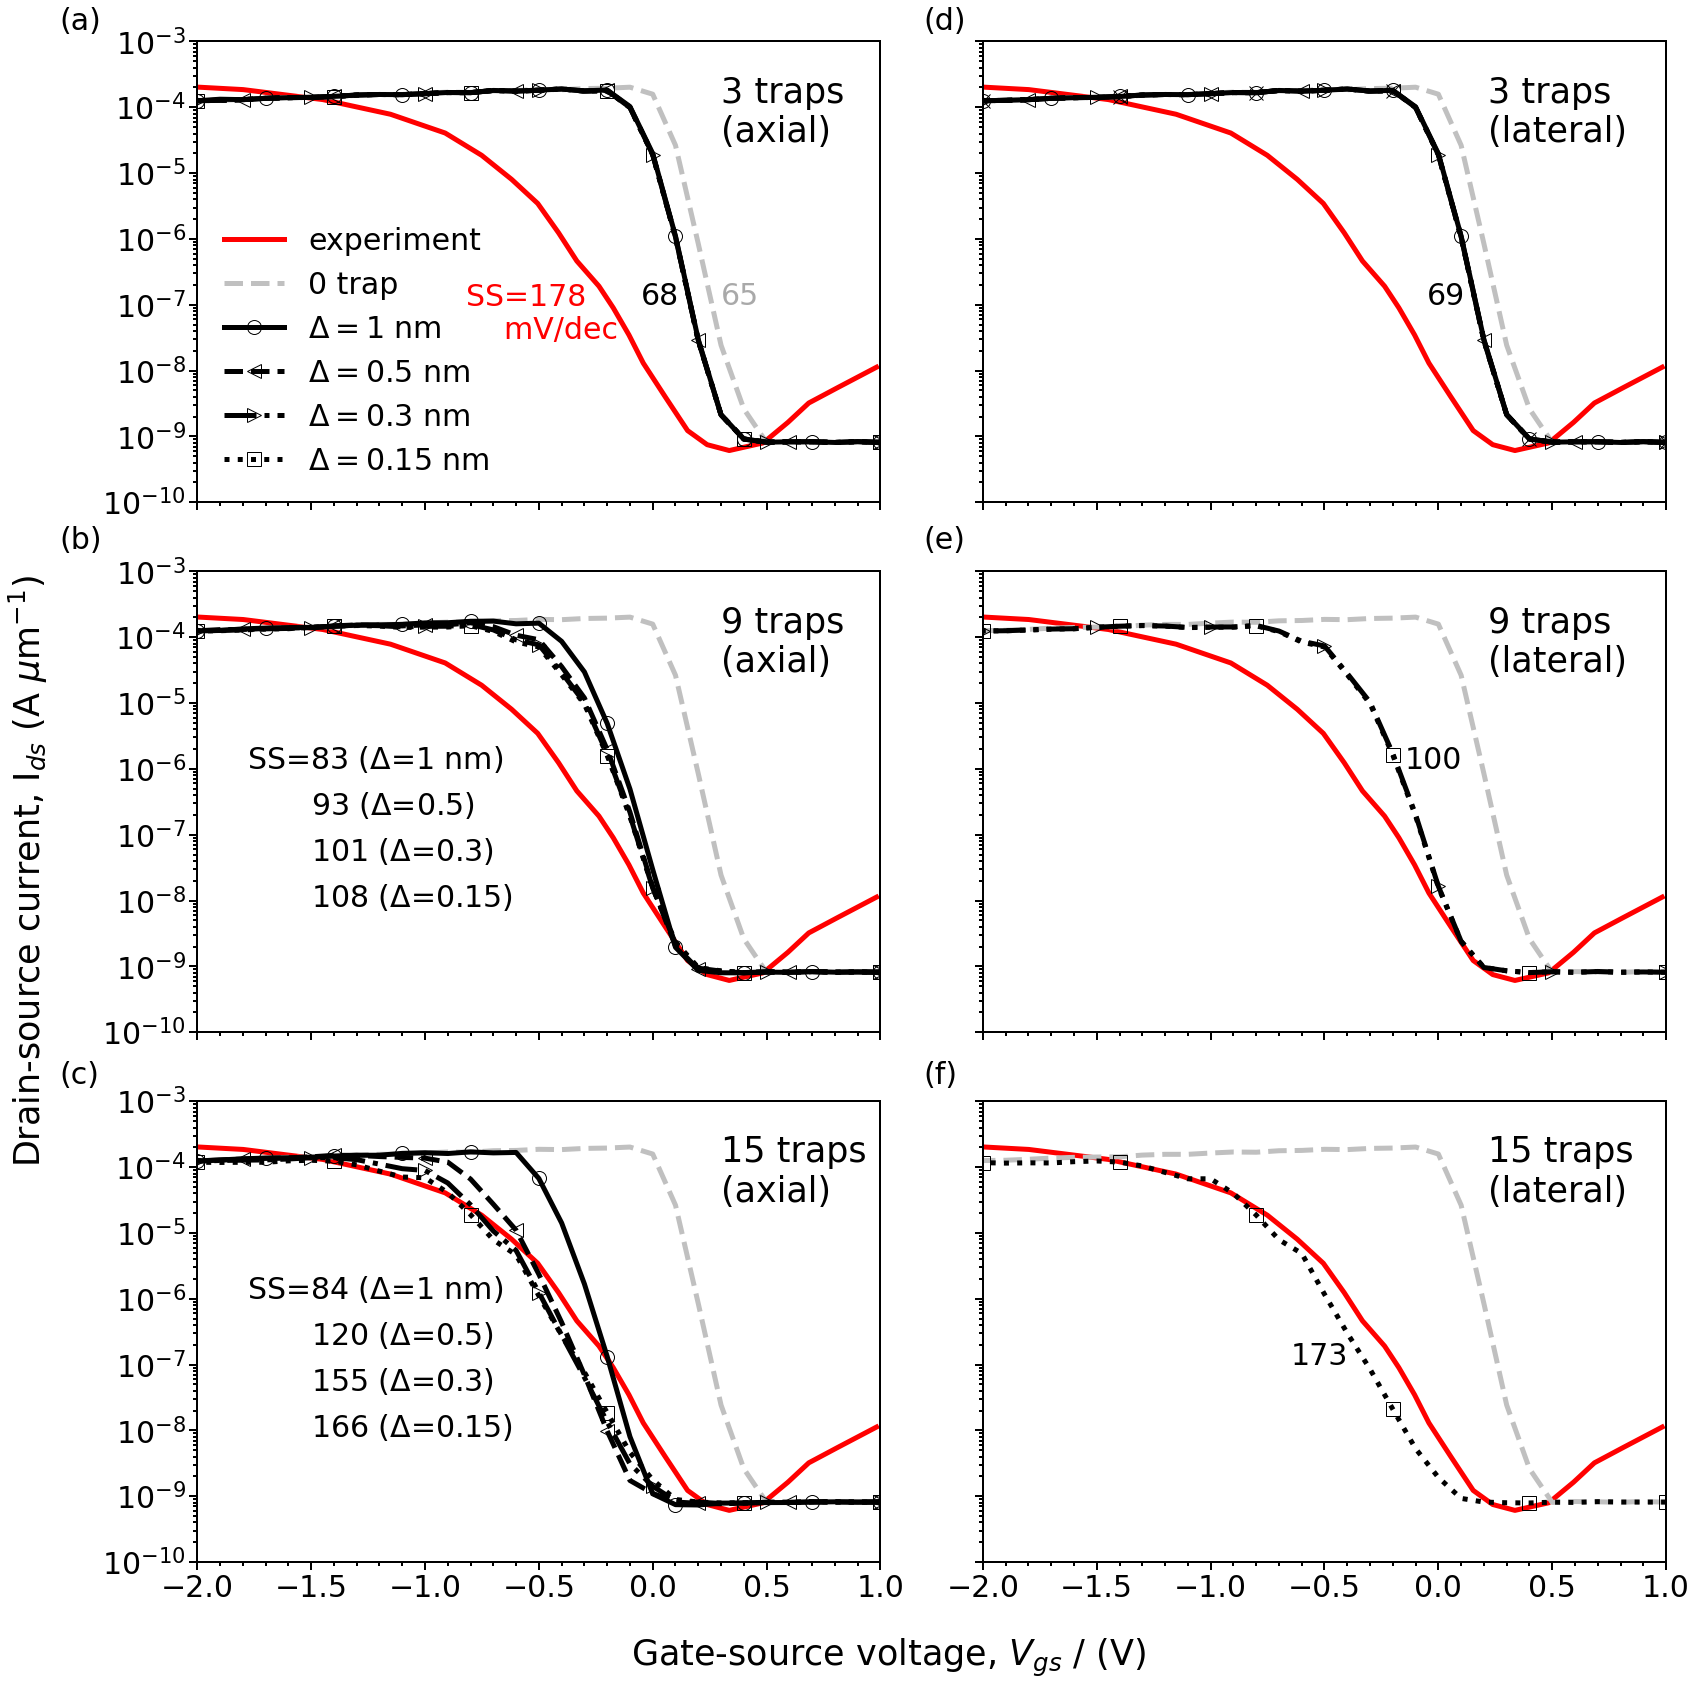

In [29]:
traps_label = [3, 9, 15]
legends_show = [True, False, False]
# axes_label_list1 = [[None, r'I$_{ds}$ (A $\mu$m$^{-1}$)'],
#                    [None, r'I$_{ds}$ (A $\mu$m$^{-1}$)'],
#                    [r'$V_{gs}$ / (V)', r'I$_{ds}$ (A $\mu$m$^{-1}$)']]

# axes_label_list2 = [[None, None],
#                    [None, None],
#                    [r'$V_{gs}$ / (V)', None]]
y_label_placement = [1, 0.7, 0.39]

if PrintFigures:
    fig, axs = plt.subplots(3, 2, figsize=(24, 24), sharex=True, sharey=True)
    # ['darkcyan','brown','dodgerblue','mediumorchid']

    # First column: Your original 3 plots
    for i, folder_range in enumerate([range(SPACINGS), range(SPACINGS, 2*SPACINGS), range(2*SPACINGS, 3*SPACINGS)]):
        plt, pltname = custom_plot_single(fig, axs[i, 0],
                                          [Vgs_exp] + [Vgs_notrap] + [(Vgs[folder][0:pts[folder]]) for folder in folder_range], 
                                          [Ids_exp] + [Ids_appx_notrap] + [Ids_appx[folder][0:pts[folder]] for folder in folder_range],
                                          [label_str_exp] + [label_str_notrap] + [', '.join(label_str[folder].split(',')) for folder in folder_range],
                                          [-2, 1.],
                                          [1e-10, 1e-3],
                                          [None,None],
                                          f'L95_{(i + 3)*3}traps.png',
                                          color=['r'] + ['silver'] + ['k','k','k','k'],
                                          linestyle=['solid'] + ['dashed'] + ['solid', 'dashed', 'dashdot', 'dotted'],
                                          markertype=[None] + [None] + ['o', '<', '>', 's'],
                                          markevery=[1] + [1] + [3,4,5,6],
                                          linewidth=[5]*16,
                                          fillstyle=['full']*16,                                     
                                          show_legend=legends_show[i],
                                          plt_outside=True, y_logscale=True)
        # Place labels at the top-left corner
        fig.text(0.02, y_label_placement[i], f'({chr(97 + i)})', fontsize=30, color='k', va='top', ha='left')
        # Adding the correct figure labels inside the figure
        axs[i, 0].text(0.3, 3e-5, f'{traps_label[i]} traps\n(axial)', fontsize=35, color='k')
    
    # Second column Fig (d)
    folder_range = range(12,16)        
    i=0
    plt, pltname = custom_plot_single(fig, axs[i, 1],
                                      [Vgs_exp] + [Vgs_notrap] + [(Vgs[folder][0:pts[folder]]) for folder in folder_range], 
                                      [Ids_exp] + [Ids_appx_notrap] + [Ids_appx[folder][0:pts[folder]] for folder in folder_range],
                                      [label_str_exp] + [label_str_notrap] + [', '.join(label_str[folder].split(',')) for folder in folder_range],
                                      [-2, 1.],
                                      [1e-10, 1e-3],
                                      [None,None],
                                      f'L95_{(i + 3)*3}traps.png',
                                      color=['r'] + ['silver'] + ['k','k','k','k'],
                                      linestyle=['solid'] + ['dashed'] + ['solid', 'dashed', 'dashdot', 'dotted'],
                                      markertype=[None] + [None] + ['o', '<', '>', 'x'],
                                      markevery=[1] + [1] + [3,4,5,6],
                                      linewidth=[5]*16,
                                      fillstyle=['full']*16,                                     
                                      show_legend=False,
                                      plt_outside=True, y_logscale=True)
    # Place labels at the top-left corner
    fig.text(0.52, y_label_placement[i], f'({chr(100 + i)})', fontsize=30, color='k', va='top', ha='left')
    # Adding the correct figure labels inside the figure
    axs[i, 1].text(0.22, 3e-5, f'{traps_label[i]} traps\n(lateral)', fontsize=35, color='k')
    # Second column Fig (e)  
    folder_range = [16,17]
    i=1
    plt, pltname = custom_plot_single(fig, axs[i, 1],
                                      [Vgs_exp] + [Vgs_notrap] + [(Vgs[folder][0:pts[folder]]) for folder in folder_range], 
                                      [Ids_exp] + [Ids_appx_notrap] + [Ids_appx[folder][0:pts[folder]] for folder in folder_range],
                                      [None] + [None] + [', '.join(label_str[folder].split(',')) for folder in folder_range],
                                      [-2, 1.],
                                      [1e-10, 1e-3],
                                      [None,None],
                                      f'L95_{(i + 3)*3}traps.png',
                                      color=['r'] + ['silver'] + ['k','k'],
                                      linestyle=['solid'] + ['dashed'] + ['dashdot', 'dotted'],
                                      markertype=[None] + [None] + ['>', 's'],
                                      markevery=[1] + [1] + [5,6],
                                      linewidth=[5]*16,
                                      fillstyle=['full']*16,                                     
                                      show_legend=False,
                                      plt_outside=True, y_logscale=True)
    # Place labels at the top-left corner
    fig.text(0.52, y_label_placement[i], f'({chr(100 + i)})', fontsize=30, color='k', va='top', ha='left')
    # Adding the correct figure labels inside the figure
    axs[i, 1].text(0.22, 3e-5, f'{traps_label[i]} traps\n(lateral)', fontsize=35, color='k')   


    # Second column Fig (f)      
    folder_range = [18]    
    i=2
    plt, pltname = custom_plot_single(fig, axs[i, 1],
                                      [Vgs_exp] + [Vgs_notrap] + [(Vgs[folder][0:pts[folder]]) for folder in folder_range], 
                                      [Ids_exp] + [Ids_appx_notrap] + [Ids_appx[folder][0:pts[folder]] for folder in folder_range],
                                      [None] + [None] + [', '.join(label_str[folder].split(',')) for folder in folder_range],
                                      [-2, 1.],
                                      [1e-10, 1e-3],
                                      [None,None],
                                      f'L95_{(i + 3)*3}traps.png',
                                      color=['r'] + ['silver'] + ['k'],
                                      linestyle=['solid'] + ['dashed'] + ['dotted'],
                                      markertype=[None] + [None] + ['s'],
                                      markevery=[1] + [1] + [6],
                                      linewidth=[5]*16,
                                      fillstyle=['full']*16,                                     
                                      show_legend=False,
                                      plt_outside=True, y_logscale=True)
    # Place labels at the top-left corner
    fig.text(0.52, y_label_placement[i], f'({chr(100 + i)})', fontsize=30, color='k', va='top', ha='left')
    # Adding the correct figure labels inside the figure
    axs[i, 1].text(0.22, 3e-5, f'{traps_label[i]} traps\n(lateral)', fontsize=35, color='k')             

    ## SS labeling (mV/dec)
    axs[0, 0].text(-0.82,3e-8, r'SS=178' + '\n' + '    mV/dec', fontsize=30, color='r')
    axs[0, 0].text(-0.05, 1e-7, r'68', fontsize=30, color='k')        
    axs[0, 0].text(0.3,1e-7, r'65', fontsize=30, color='darkgray')

    axs[1, 0].text(-1.78, 1e-6, r'SS=83 ($\Delta$=1 nm)', fontsize=30, color='k')
    axs[1, 0].text(-1.5, 2e-7, r'93 ($\Delta$=0.5)', fontsize=30, color='k')
    axs[1, 0].text(-1.5, 4e-8, r'101 ($\Delta$=0.3)', fontsize=30, color='k')
    axs[1, 0].text(-1.5, 8e-9, r'108 ($\Delta$=0.15)', fontsize=30, color='k')

    axs[2, 0].text(-1.78, 1e-6, r'SS=84 ($\Delta$=1 nm)', fontsize=30, color='k')
    axs[2, 0].text(-1.5, 2e-7, r'120 ($\Delta$=0.5)', fontsize=30, color='k')
    axs[2, 0].text(-1.5, 4e-8, r'155 ($\Delta$=0.3)', fontsize=30, color='k')
    axs[2, 0].text(-1.5, 8e-9, r'166 ($\Delta$=0.15)', fontsize=30, color='k')
        
    axs[0, 1].text(-0.05, 1e-7, r'69', fontsize=30, color='k')    
    axs[1, 1].text(-0.15,1e-6, r'100', fontsize=30, color='k')
    axs[2, 1].text(-0.65, 1e-7, r'173', fontsize=30, color='k')
    
    #plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to leave space for text outside
    plt.subplots_adjust(hspace=0.15, wspace=0.15)  # Increase spacing between rows (hspace) and columns (wspace)
    fig.text(0.5, 0.04, r'Gate-source voltage, $V_{gs}$ / (V)', ha='center', fontsize=35)  # X-axis label for entire figure
    fig.text(-0.01, 0.5, r'Drain-source current, I$_{ds}$ (A $\mu$m$^{-1}$)', va='center', rotation='vertical', fontsize=35)  # Y-axis label for entire figure
    fig.subplots_adjust(bottom=0.1, top=0.98, left=0.1, right=0.95)
    fig.savefig('IV_axial_lateral_traps.png', bbox_inches="tight", dpi='figure', format='png', facecolor='auto', edgecolor='auto')
    # Save the combined figure
    #plt.savefig('IV_axial_lateral_traps.png', bbox_inches="tight", dpi=300)
    plt.show()



# Subthreshold swing and ON current

Experimental ON current and SS:
ON current / (1e-4 \mu A): 0.34169596291197935
	SS (mV/decade): 177.4

folder: 0
label: $\Delta=1$ nm
ON current / (1e-4 \mu A): [1257049.06832565]
Vgs where barrier is  8 kT: 0.0588106345153917
Vgs where barrier is  12 kT: 0.1784037200792804
Vgs where phonon-tunneling barrier is 0.2 eV: 0.11858406115914884
	SS (mV/decade): 68.4

folder: 1
label: $\Delta=0.5$ nm
ON current / (1e-4 \mu A): [1257455.26718781]
Vgs where barrier is  8 kT: 0.0504289723372979
Vgs where barrier is  12 kT: 0.17167350143966495
Vgs where phonon-tunneling barrier is 0.2 eV: 0.11176380769566358
	SS (mV/decade): 69.4

folder: 2
label: $\Delta=0.3$ nm
ON current / (1e-4 \mu A): [1257524.98788804]
Vgs where barrier is  8 kT: 0.0476714818328812
Vgs where barrier is  12 kT: 0.16944477781293296
Vgs where phonon-tunneling barrier is 0.2 eV: 0.1095148215630012
	SS (mV/decade): 69.7

folder: 3
label: $\Delta=0.15$ nm
ON current / (1e-4 \mu A): [1257549.23856637]
Vgs where barrier is  8 kT: 0

/usr/lib/python3/dist-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/usr/lib/python3/dist-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


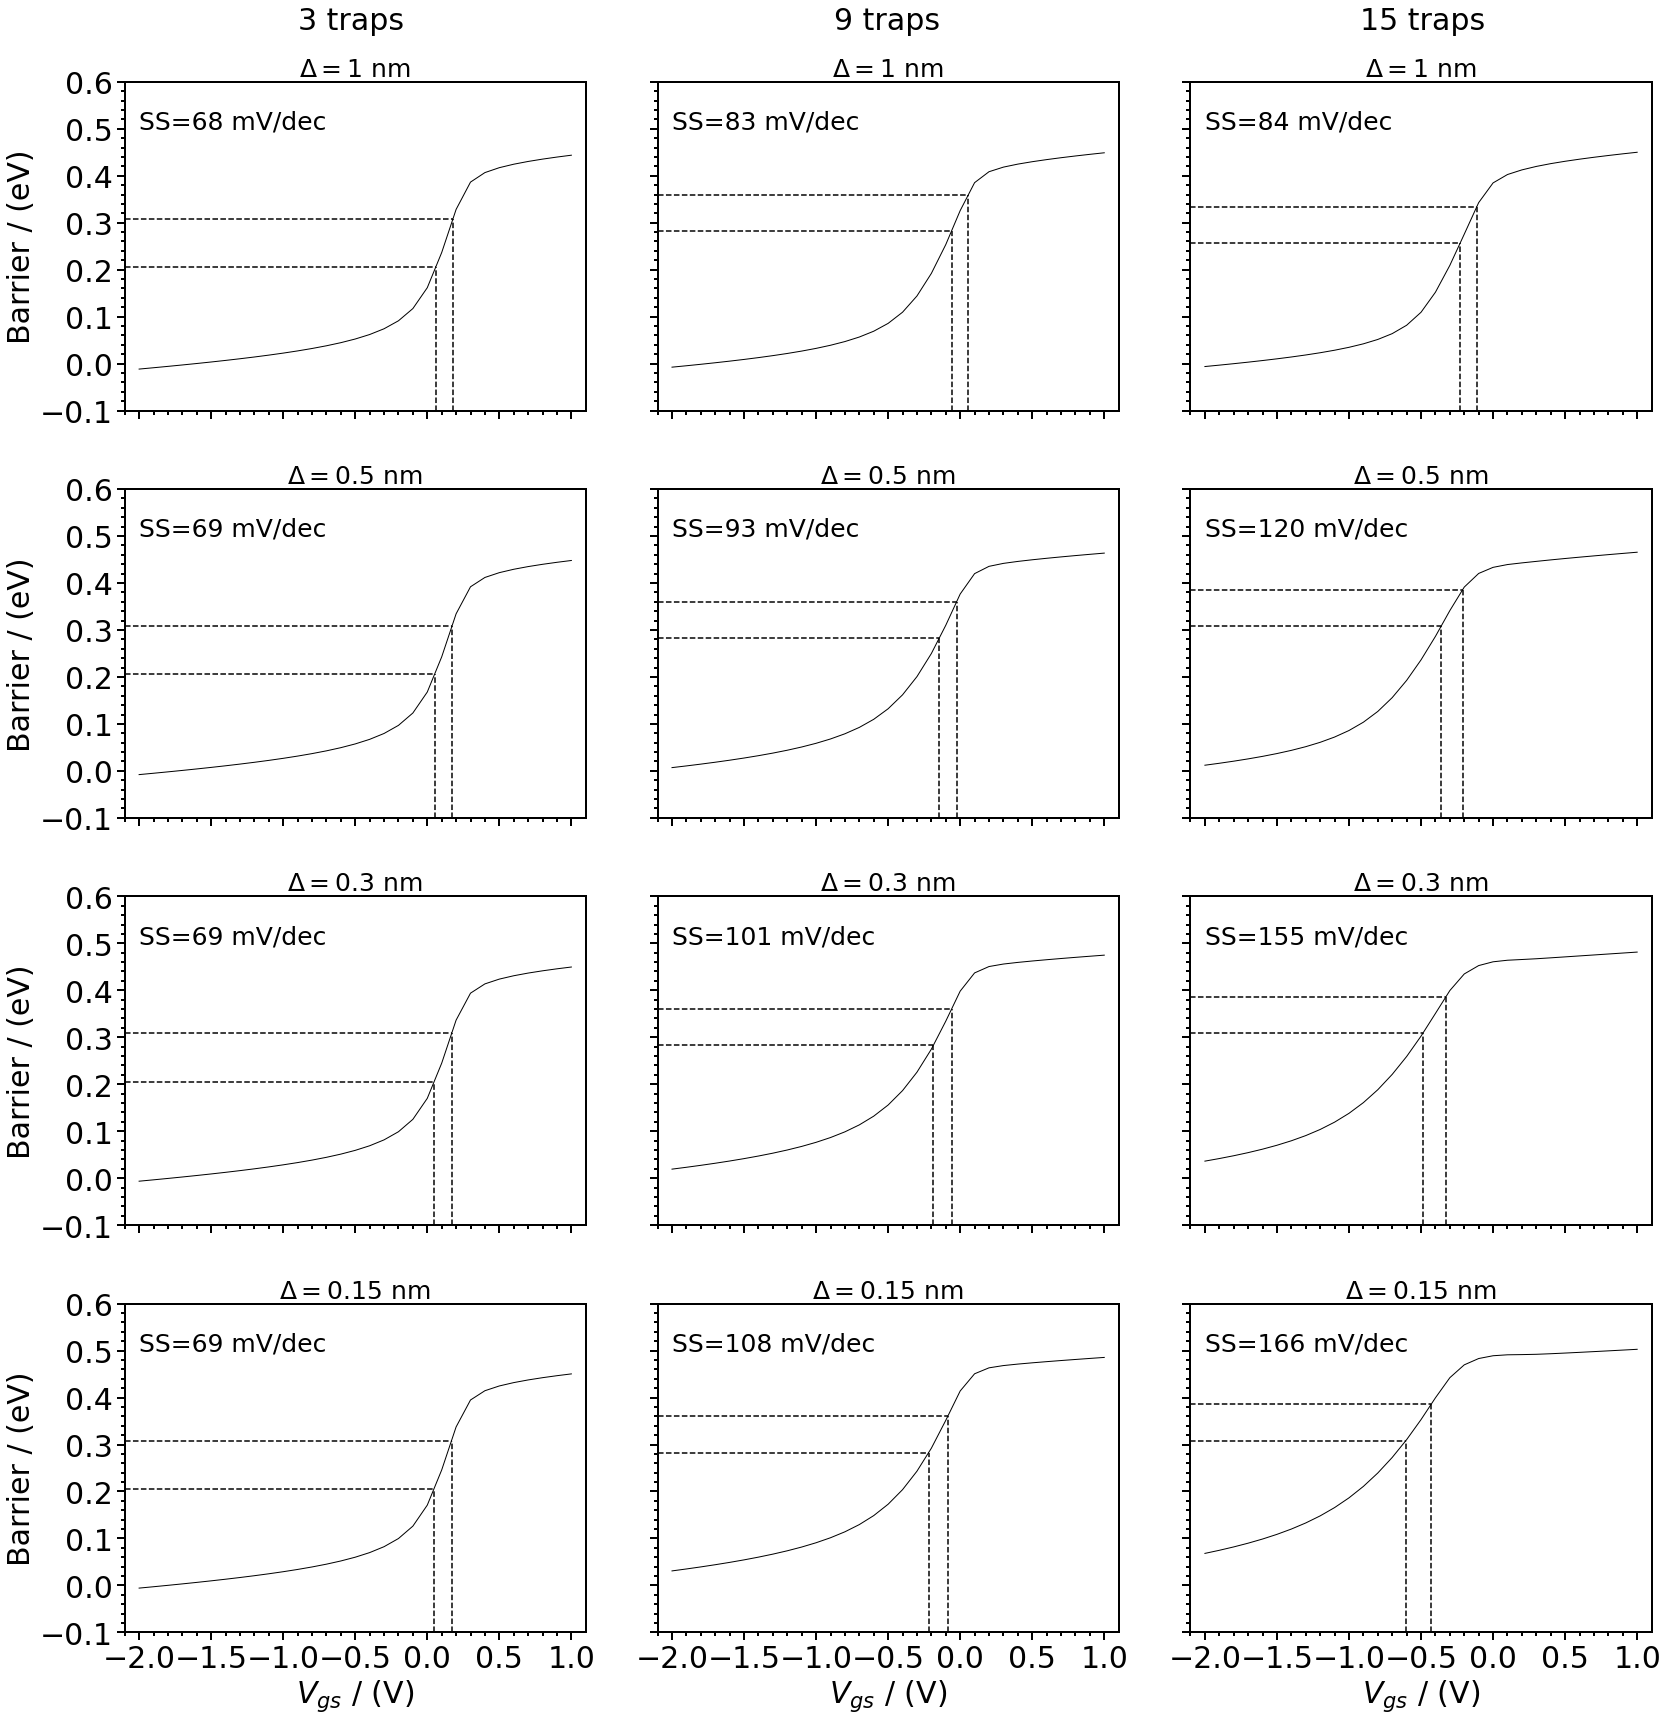

In [27]:
#ON current per micron
#SS mV/decade
print('Experimental ON current and SS:')
G_exp = Ids_exp/(G_quantum*Vds*CNTs_per_micron)
I_ON_exp = Scaling_Factor*Ids_exp[-1]
print('ON current / (1e-4 \mu A):', I_ON_exp*1e10)    
SS_exp = compute_SS(Vgs_exp, G_exp, -0.27, -0., True)


I_ON =  np.zeros((12,1),dtype=float)
SS =  np.zeros((12,1),dtype=float)

Scaling_Factor = Vds*G_quantum*CNTs_per_micron
fig, ax = plt.subplots(4, 3, figsize=(24, 24), sharex=True, sharey=True)
#fig.set_size_inches(12,8)
for folder in range(12):
    print('\nfolder:', folder)
    print('label:', label_str[folder])        
    I_ON[folder] = Scaling_Factor*G[folder][pts[folder]-1]
    print('ON current / (1e-4 \mu A):', I_ON[folder]*1e10)    

    fig_idx_i = folder % 4
    fig_idx_j = folder // 4  
    ax_ij =  ax[fig_idx_i, fig_idx_j]
    if folder < 4:
        a = 8
        b = 12
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg    
    elif folder >= 4 and folder < 8:
        a = 11
        b = 14
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg            
    elif folder == 8:
        a = 10
        b = 13
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg            
    elif folder >= 9 and folder < 12:
        a = 12#12
        b = 15#14.5
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg                    
    Ef=-0.2
    
    SS[folder] = compute_SS(Vgs[folder][:pts[folder]], G[folder][:pts[folder]], vgs_at_akT, vgs_at_bkT, True)
    ax_ij.text(-2, 0.5, r'SS=%d'%(SS[folder]) + ' mV/dec', fontsize=25, color='k')
    ax_ij.set_title(f"{label_str[folder]}", fontsize=25)
    if fig_idx_j > 0:
        ax_ij.set_ylabel('')              
    if fig_idx_i < 3:
        ax_ij.set_xlabel('')
    
# Add labels for each column
fig.text(0.22, 1, '3 traps', ha='center', va='center', fontsize=30)  # Label for the 1st column
fig.text(0.53, 1, '9 traps', ha='center', va='center', fontsize=30)  # Label for the 2nd column
fig.text(0.84, 1, '15 traps', ha='center', va='center', fontsize=30)  # Label for the 3rd column
plt.tight_layout(pad=3.0)  # Adjust padding to prevent overlap of axes labels and ticks
plt.savefig('TransportBarrier_SS_AxialTraps.png', bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')


The above figure is just for understanding how I chose vgs values to calculate subthreshold swing (SS).
The black curve shows the Transport barrier as the barrier between the valence-band-edge-in-the-center-of-the-channel and the Fermi level.

The projections of black dashed line onto the X axis which is the gate-source voltage shows the two voltages I chose to calculate SS.
The projections onto the y axis (Barrier) shows the how much the valence-band-edge-in-the-center-of-the-channel changes with respect to the Fermi level which is E_F=-0.2 eV for this case (set as the input while running the simulations).

I tried to choose a linearly varying region to calculate SS by first setting parameters a and b which are factors multiplied by kT associated with the Y projections. These factors change depending on how the IV characteristics are shifted. Therefore there is some ambiguity in selecting values. This visualization helps in realizing that I chose a roughly linearly varying region. 

These plots are for axial orientation of traps.
First column corresponds to 3 traps. 
Second column corresponds to 9 traps.
Third column corresponds to 15 traps. 
1-4 rows correspond to Delta x = 1, 0.5, 0.3, 0.15 nm spacing.


folder: 12
label: $\Delta=1$ nm
ON current / (1e-4 \mu A): [1257446.17318344]
Vgs where barrier is  8 kT: 0.05059302294449947
Vgs where barrier is  12 kT: 0.1718090090875411
Vgs where phonon-tunneling barrier is 0.2 eV: 0.11195545579357989
	SS (mV/decade): 69.4

folder: 13
label: $\Delta=0.5$ nm
ON current / (1e-4 \mu A): [1257518.92521845]
Vgs where barrier is  8 kT: 0.04769736842105263
Vgs where barrier is  12 kT: 0.16946810483035418
Vgs where phonon-tunneling barrier is 0.2 eV: 0.10956037124690537
	SS (mV/decade): 69.7

folder: 14
label: $\Delta=0.3$ nm
ON current / (1e-4 \mu A): [1257543.17589679]
Vgs where barrier is  8 kT: 0.04655412088646509
Vgs where barrier is  12 kT: 0.16854134846170632
Vgs where phonon-tunneling barrier is 0.2 eV: 0.10861335369845082
	SS (mV/decade): 69.9

folder: 15
label: $\Delta=0.15$ nm
ON current / (1e-4 \mu A): [1257555.30123596]
Vgs where barrier is  8 kT: 0.04599152734902242
Vgs where barrier is  12 kT: 0.16808519924926893
Vgs where phonon-tunneling

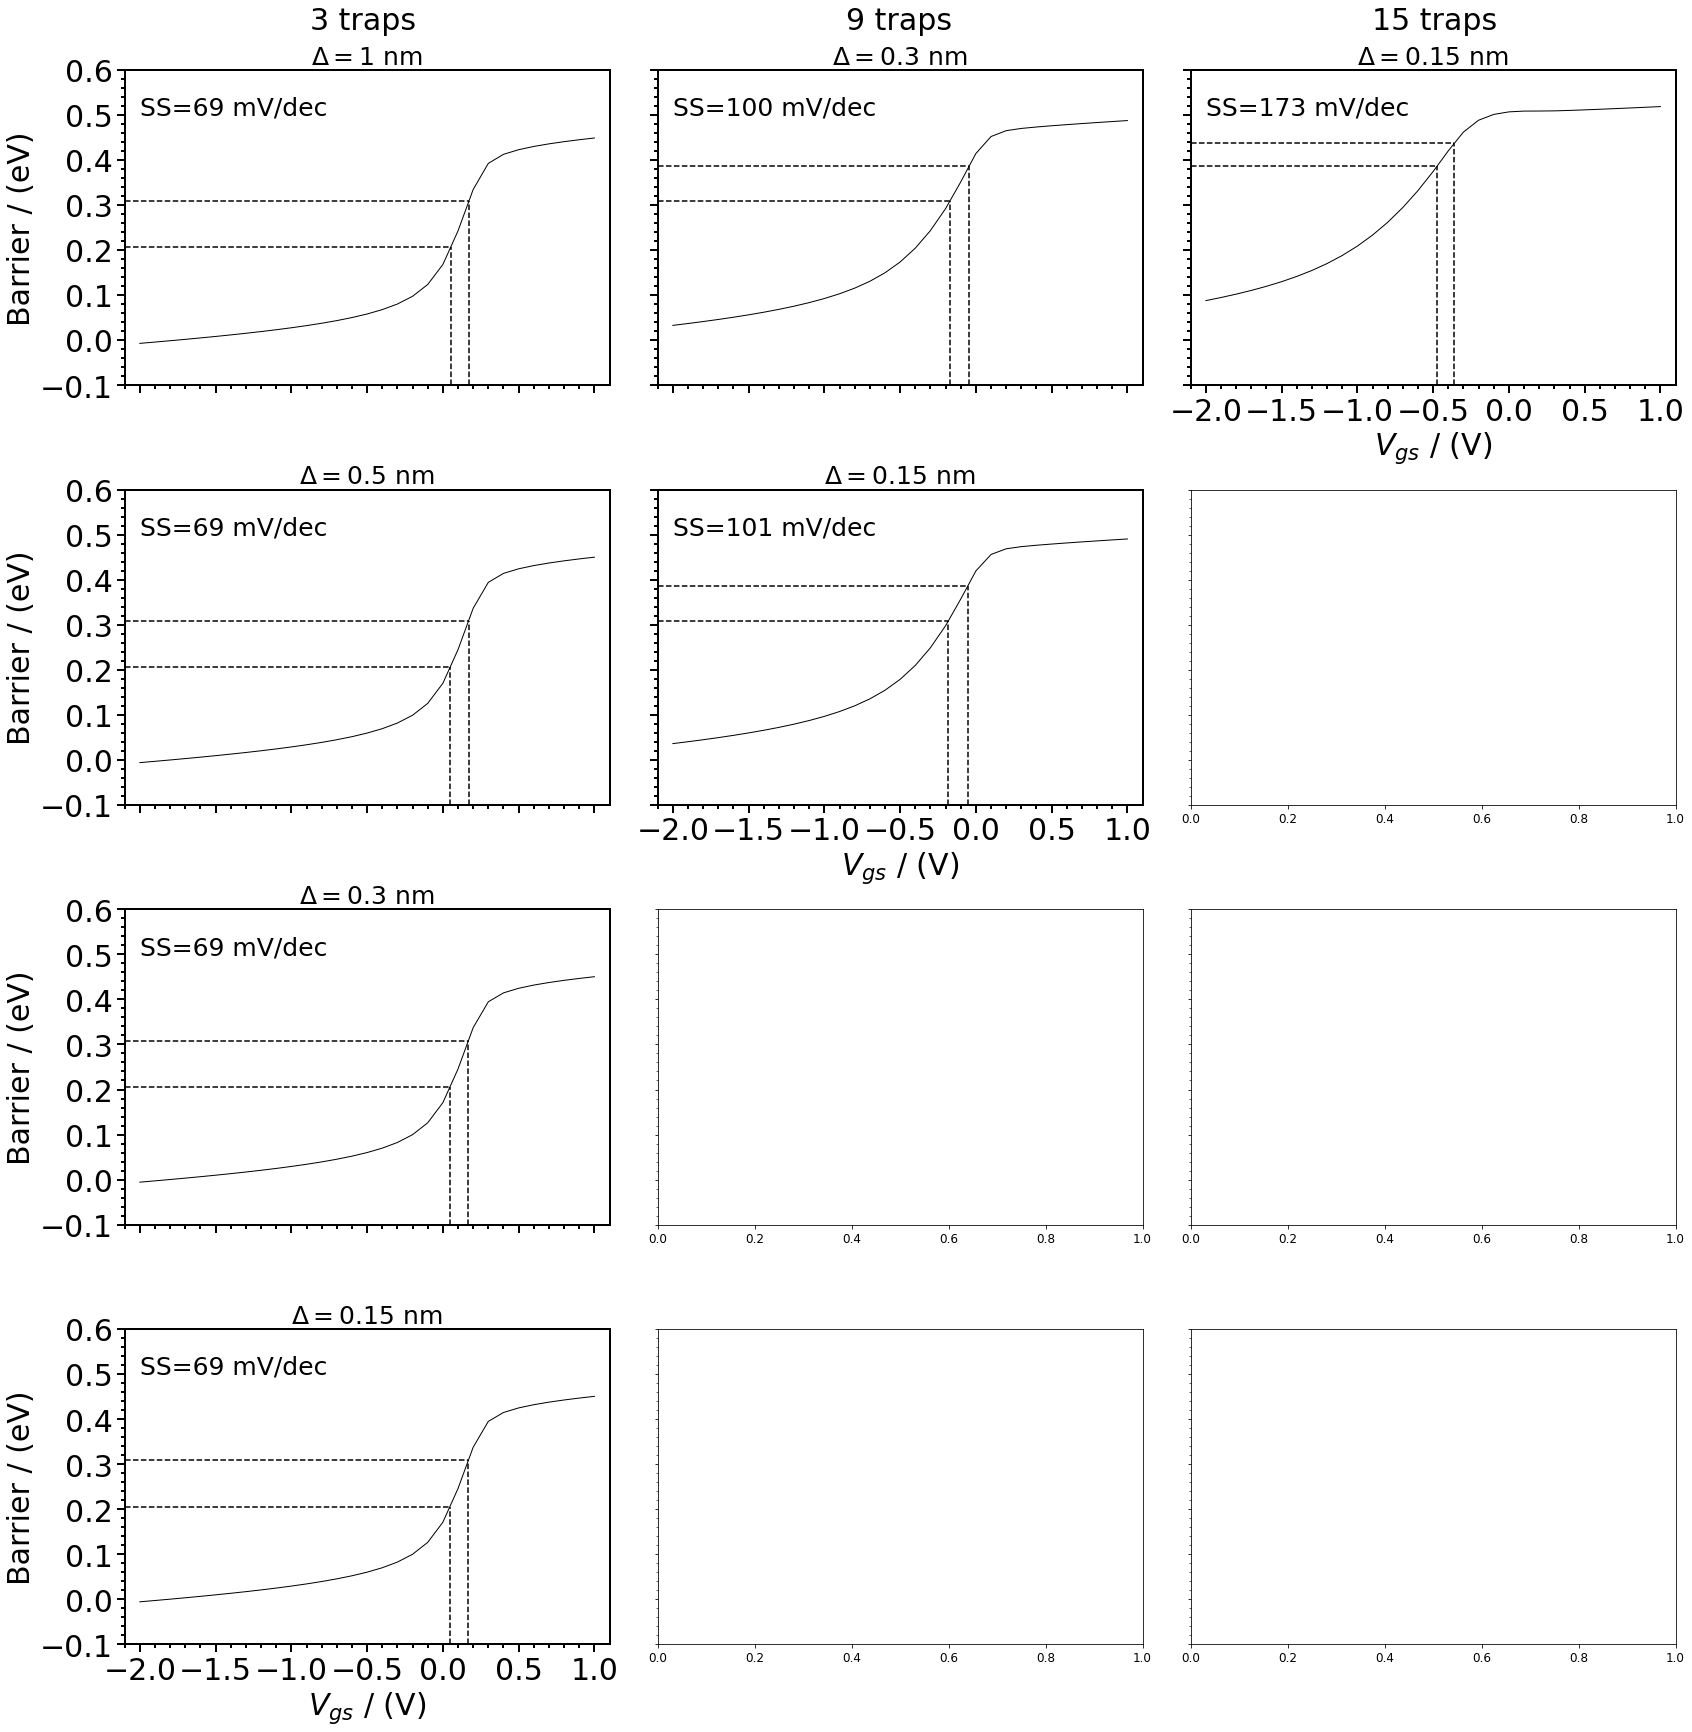

In [16]:
#ON current per micron
#SS mV/decade
I_ON_lateral =  np.zeros((7,1),dtype=float)
SS_lateral =  np.zeros((7,1),dtype=float)

Scaling_Factor = Vds*G_quantum*CNTs_per_micron
fig, ax = plt.subplots(4, 3, figsize=(24, 24), sharex=False, sharey=True)
#fig.set_size_inches(12,8)

ax[3, 0].get_shared_y_axes().join(ax[0, 0], ax[1, 0], ax[2, 0], ax[3, 0])  # Share x-axis for each subplot in first column

counter=0
for folder in range(12,19):
    print('\nfolder:', folder)
    print('label:', label_str[folder])        
    I_ON_lateral[counter] = Scaling_Factor*G[folder][pts[folder]-1]
    print('ON current / (1e-4 \mu A):', I_ON_lateral[counter]*1e10)    

    fig_idx_i = folder % 4
    fig_idx_j = folder // 4 - 3
    ax_ij =  ax[fig_idx_i, fig_idx_j]
    if counter < 4:
        a = 8
        b = 12
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg    
    elif counter >= 4 and counter < 6:
        a = 12
        b = 15
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg            
    elif counter == 6:
        fig_idx_i = 0
        fig_idx_j = 2
        ax_ij =  ax[fig_idx_i, fig_idx_j]
        a = 15
        b = 17
        vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], fig, ax_ij, Ef=Ef, a=a, b=b, Print=True) #avg            
    Ef=-0.2
    # Remove spines and ticks for empty subplots
    if (fig_idx_j == 1 and fig_idx_i > 1) or (fig_idx_j == 2 and fig_idx_i > 0):
        # Remove all spines (borders) and ticks for empty subplots
        for spine in ax_ij.spines.values():
            spine.set_visible(False)
        ax_ij.set_xticks([])  # Remove x-axis ticks
        ax_ij.set_yticks([])  # Remove y-axis ticks
        ax_ij.set_xticklabels([])  # Optionally, remove x-axis labels
        ax_ij.set_yticklabels([])  # Optionally, remove y-axis labels
    
    SS_lateral[counter] = compute_SS(Vgs[folder][:pts[folder]], G[folder][:pts[folder]], vgs_at_akT, vgs_at_bkT, True)
    ax_ij.text(-2, 0.5, r'SS=%d'%(SS_lateral[counter]) + ' mV/dec', fontsize=25, color='k')
    ax_ij.set_title(f"{label_str[folder]}", fontsize=25)
    if fig_idx_j > 0:
        ax_ij.set_ylabel('')     
    if (fig_idx_i < 3 and fig_idx_j==0) or (fig_idx_i < 1 and fig_idx_j==1):
        ax_ij.set_xlabel('')
        ax_ij.set_xticklabels('')                              
    counter += 1


# Add labels for each column
fig.text(0.22, 1, '3 traps', ha='center', va='center', fontsize=30)  # Label for the 1st column
fig.text(0.53, 1, '9 traps', ha='center', va='center', fontsize=30)  # Label for the 2nd column
fig.text(0.84, 1, '15 traps', ha='center', va='center', fontsize=30)  # Label for the 3rd column
plt.tight_layout(pad=2.0)  # Adjust padding to prevent overlap of axes labels and ticks
plt.savefig('TransportBarrier_SS_LateralTraps.png', bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')


# Band structure

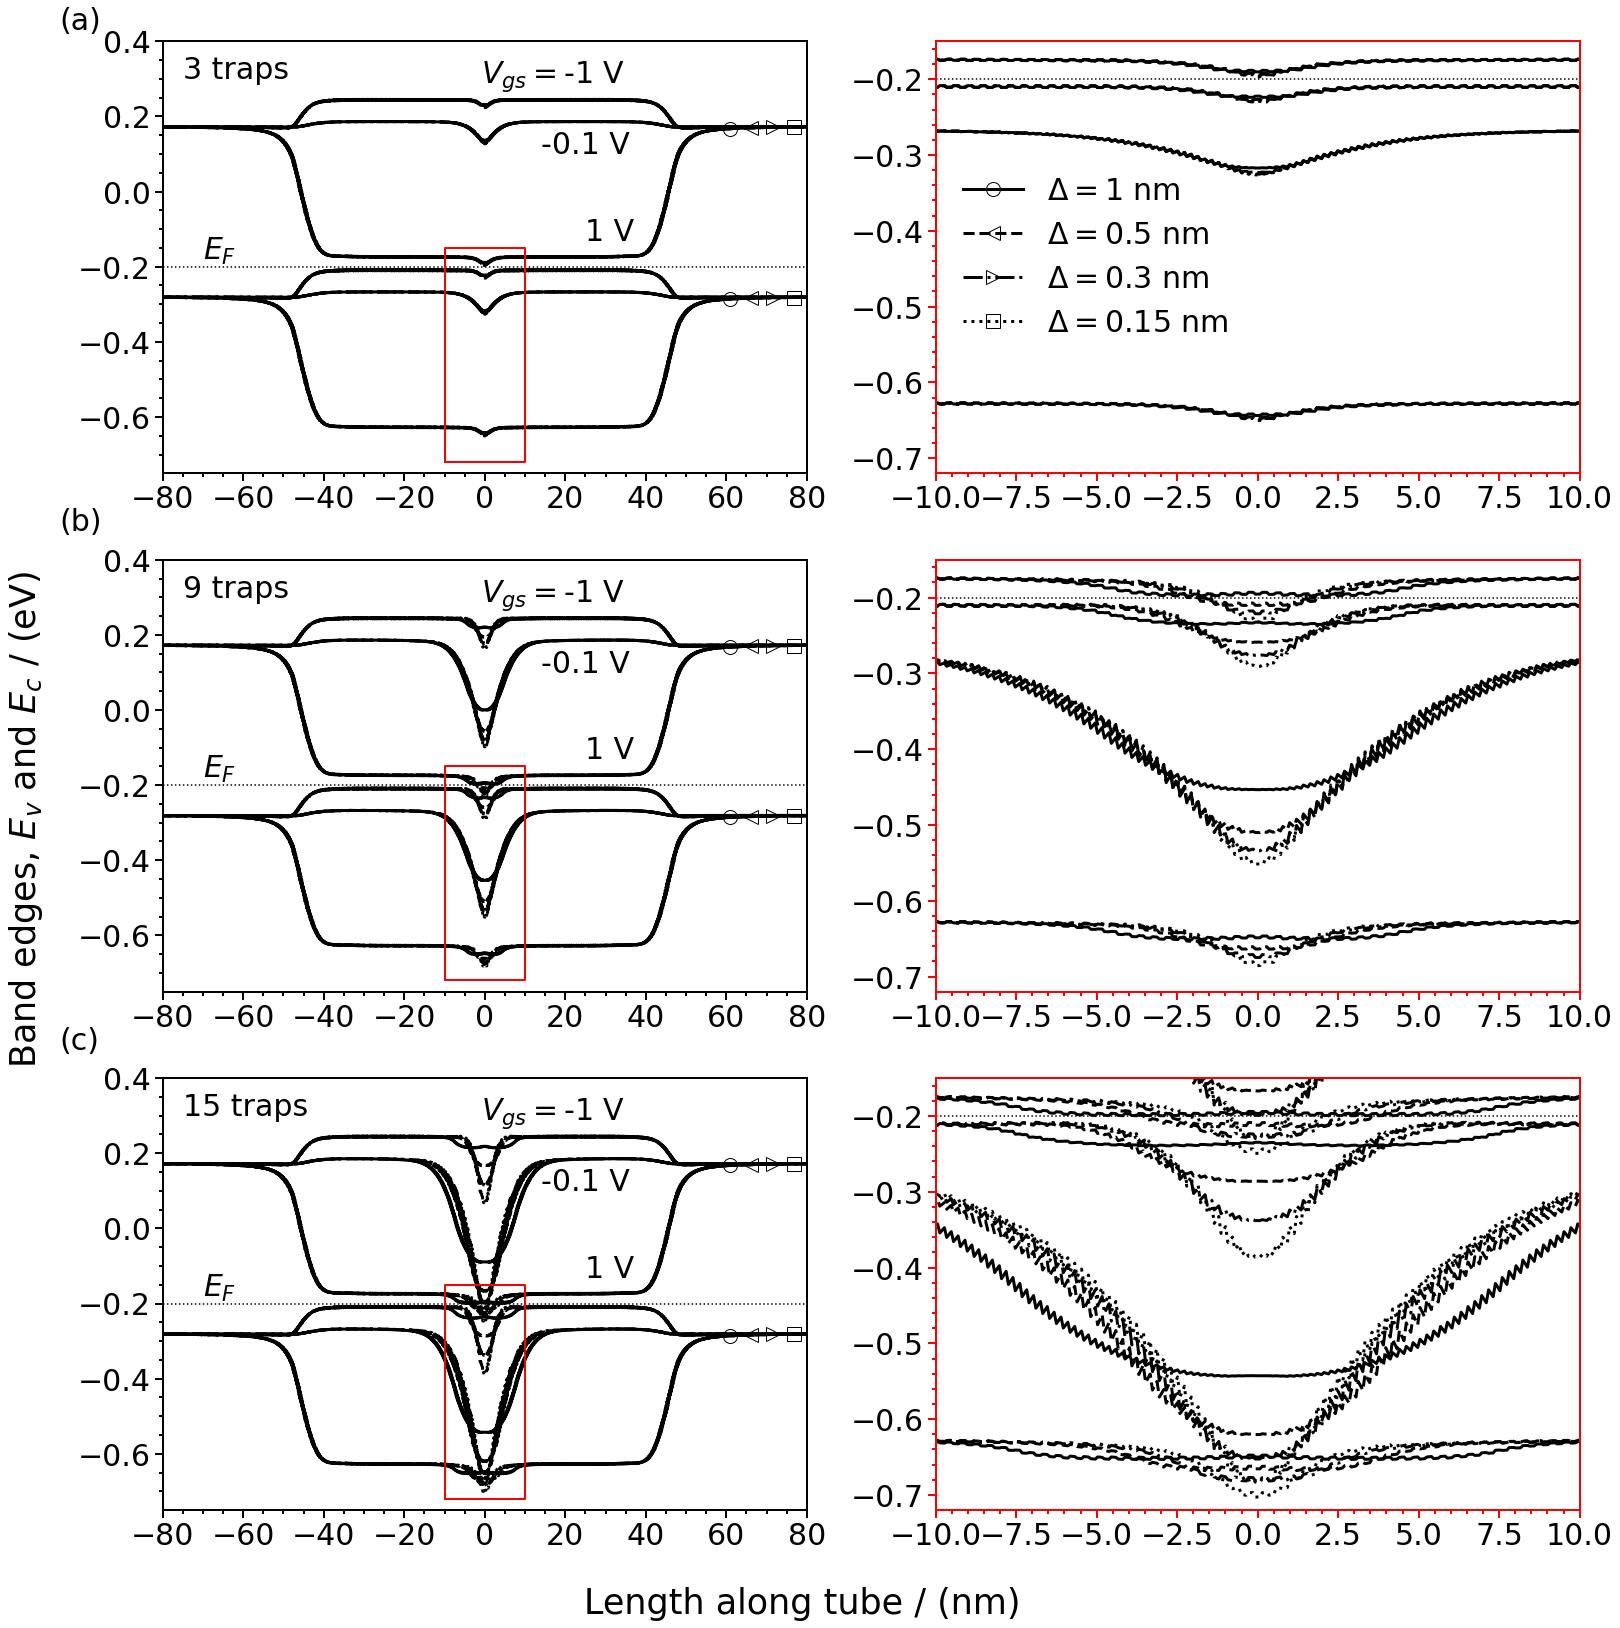

In [11]:
def create_bandstructure_plot(fig, ax, pltname, folders, Xmin,Xmax,Ymin,Ymax, colors=['k','k','k','k'], 
                              markers= ['o', '<', '>', 's'], lw=3, show_axes_labels=True, fs=30, secolor='k', annotate=False, show_legend=False):
    i = 0
    j = 11
    k = 20  

    axes_labels = [r'Length along tube / (nm)', r'Band edges, $E_v$ and $E_c$ / (eV)']
    if not show_axes_labels:
        axes_labels = [None,None]

    Y_concat = []
    EvEc_concat = []
    label_concat = []
    color_concat = []
    marker_concat = []    
    ls_concat = []
    mark_every = np.array([1403, 1453, 1503, 1553])
    mark_every_concat = []
    counter=0
    ls_array = np.array(['solid', 'dashed', 'dashdot', 'dotted'])
    for folder in folders:
        #print('Vgs_1trap at ijk:', Vgs[folder][i], Vgs[folder][j], Vgs[folder][k])        
        Y_concat.extend([Y[folder][i], Y[folder][j], Y[folder][k], Y[folder][i], Y[folder][j], Y[folder][k]])
        EvEc_concat.extend([Ev[folder][i], Ev[folder][j], Ev[folder][k], Ec[folder][i], Ec[folder][j], Ec[folder][k]])
        label_concat.extend([label_str[folder], None, None, None, None, None])
        color = colors[counter%4]
        color_concat.extend([color, color, color, color, color, color])
        ls = ls_array[counter%4]
        ls_concat.extend([ls, ls, ls, ls, ls, ls])
        marker = markers[counter%4]
        marker_concat.extend([marker, '', '', marker, '', ''])
        ME = mark_every[counter%4]
        mark_every_concat.extend([ME, 10000, 10000, ME, 10000, 10000])
        counter+=1
    
    # Custom plot function for main curves
    plt, pltname = custom_plot_single(fig, ax,
                                      Y_concat, 
                                      EvEc_concat, 
                                      label_concat,
                                      [Xmin, Xmax],
                                      [Ymin, Ymax],
                                      axes_labels,
                                      pltname,
                                      color=color_concat,
                                      linestyle=ls_concat,
                                      markertype=marker_concat,
                                      fillstyle=[None] * 40,
                                      markevery=mark_every_concat,
                                      linewidth=[lw]*40,
                                      show_legend=show_legend,
                                      plt_outside=True, y_logscale=False, fontsize=fs, spine_edgecolor=secolor)
    ax.axhline(y=Ef, color='k', linestyle='dotted')
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Adding text annotations
    if annotate:
        ax.text(25, -0.13, r'1 V', fontsize=30, color='k')
        ax.text(14, 0.1, r'-0.1 V', fontsize=30, color='k')    
        ax.text(-1, 0.29, r'$V_{gs}=$-1 V', fontsize=30, color='k')
        ax.text(-70, -0.18, r'$E_{F}$', fontsize=30, color='k')

    #fig.savefig(pltname, bbox_inches="tight", dpi='figure', format='eps', pad_inches=0.1, facecolor='auto', edgecolor='auto')

fig, axs = plt.subplots(3, 2, figsize=(24, 24))

if PrintFigures:
    y_label_placement = [0.97, 0.68, 0.38]
    folder_range = range(SPACINGS)
    box = [-10, 10, -0.72, -0.15]    
    ax = axs[0,0]
    pltname = 'bandedge'
    pltname_zoom = 'bandedge_zoom'
    create_bandstructure_plot(fig, ax, pltname='bandedge3traps', folders=folder_range, Xmin=-80, Xmax=80, Ymin=-0.75, Ymax=0.4, lw=3, 
                              show_axes_labels=False, fs=30, annotate=True)
    ax.text(-75, 0.3, r'3 traps', fontsize=30, color='k')
    # Draw a red box around the region of interest    
    ax.plot([box[0], box[1], box[1], box[0], box[0]], [box[2], box[2], box[3], box[3], box[2]], 'r-', linewidth=2)  # Red box
    fig.text(0.07, y_label_placement[0], f'({chr(97)})', fontsize=30, color='k', va='top', ha='left')
    fig.text(0.07, y_label_placement[1], f'({chr(98)})', fontsize=30, color='k', va='top', ha='left')
    fig.text(0.07, y_label_placement[2], f'({chr(99)})', fontsize=30, color='k', va='top', ha='left')
    
    folder_range = range(SPACINGS, 2*SPACINGS)
    ax = axs[1,0]
    pltname = 'bandedge'
    pltname_zoom = 'bandedge_zoom'
    create_bandstructure_plot(fig, ax, pltname='bandedge9traps', folders=folder_range, Xmin=-80, Xmax=80, Ymin=-0.75, Ymax=0.4, lw=3, 
                              show_axes_labels=False, fs=30, annotate=True)
    ax.text(-75, 0.3, r'9 traps', fontsize=30, color='k')    
    ax.plot([box[0], box[1], box[1], box[0], box[0]], [box[2], box[2], box[3], box[3], box[2]], 'r-', linewidth=2)  # Red box
   
    folder_range = range(2*SPACINGS, 3*SPACINGS)
    ax = axs[2,0]
    pltname = 'bandedge'
    pltname_zoom = 'bandedge_zoom'
    create_bandstructure_plot(fig, ax, pltname='bandedge15traps', folders=folder_range, Xmin=-80, Xmax=80, Ymin=-0.75, Ymax=0.4, lw=3, 
                              show_axes_labels=False, fs=30, annotate=True)
    ax.text(-75, 0.3, r'15 traps', fontsize=30, color='k')        
    ax.plot([box[0], box[1], box[1], box[0], box[0]], [box[2], box[2], box[3], box[3], box[2]], 'r-', linewidth=2)  # Red box

    # Draw zooms
    folder_range = range(SPACINGS)    
    box = [-10, 10, -0.72, -0.15]
    ax_zoom = axs[0,1]    
    create_bandstructure_plot(fig, ax_zoom,  pltname='bandedge_zoom3traps', folders=folder_range, Xmin=box[0], Xmax=box[1], Ymin=box[2], Ymax=box[3], lw=3, 
                              show_axes_labels=False, fs=30, secolor='r', annotate=False, show_legend=True)
    
    folder_range = range(SPACINGS, 2*SPACINGS)    
    box = [-10, 10, -0.72, -0.15]
    ax_zoom = axs[1,1]    
    create_bandstructure_plot(fig, ax_zoom,  pltname='bandedge_zoom9traps', folders=folder_range, Xmin=box[0], Xmax=box[1], Ymin=box[2], Ymax=box[3], lw=3, 
                              show_axes_labels=False, fs=30, secolor='r', annotate=False)
 
    folder_range = range(2*SPACINGS, 3*SPACINGS)    
    box = [-10, 10, -0.72, -0.15]
    ax_zoom = axs[2,1]    
    create_bandstructure_plot(fig, ax_zoom,  pltname='bandedge_zoom15traps', folders=folder_range, Xmin=box[0], Xmax=box[1], Ymin=box[2], Ymax=box[3], lw=3, 
                              show_axes_labels=False, fs=30, secolor='r', annotate=False)

#plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to leave space for text outside
#plt.subplots_adjust(hspace=0.15, wspace=0.15)  # Increase spacing between rows (hspace) and columns (wspace)


# Add figure-wide labels using fig.text
fig.text(0.5, 0.04, r'Length along tube / (nm)', ha='center', fontsize=35)  # X-axis label for entire figure
fig.text(0.04, 0.5, r'Band edges, $E_v$ and $E_c$ / (eV)', va='center', rotation='vertical', fontsize=35)  # Y-axis label for entire figure
fig.subplots_adjust(bottom=0.1, top=0.95, left=0.13, right=0.95)
fig.savefig('bandedge_axial_traps.png', bbox_inches="tight", dpi='figure', format='png', pad_inches=0.05, facecolor='auto', edgecolor='auto')
plt.show()